<a href="https://colab.research.google.com/github/M4rck0/Procesamiento_Clasificacion_Datos/blob/main/Tarea_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!python -m spacy download es_core_news_sm

In [31]:
# Librerías

# Base
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import spacy # Procesamiento de lenguaje natural
import re # Buscar, reemplazar o eliminar patrones (expresiones regulares)
from collections import Counter # Contador
from sklearn.metrics.pairwise import cosine_similarity # Calcular similitudes
from sklearn.feature_extraction.text import TfidfVectorizer # Convertir texto a números

In [9]:
# Identificar verbos, sustantivos, etc en español
nlp = spacy.load("es_core_news_sm")

# Canciones

In [4]:
# Letras de canciones
letra_cielito_lindo = """De la Sierra Morena, cielito lindo, vienen bajando Un par de ojitos negros, cielito lindo, de contrabando De la Sierra Morena, cielito lindo, vienen bajando Un par de ojitos negros, cielito lindo, de contrabando Ay, ay, ay, ay Canta y no llores Porque cantando se alegran, cielito lindo, los corazones Ay, ay, ay, ay Canta y no llores Porque cantando se alegran, cielito lindo, los corazones Ese lunar que tienes, cielito lindo, junto a la boca No se lo des a nadie, cielito lindo, que a mí me toca Ese lunar que tienes, cielito lindo, junto a la boca No se lo des a nadie, cielito lindo, que a mí me toca Ay, ay, ay, ay Canta y no llores Porque cantando se alegran, cielito lindo, los corazones Ay, ay, ay, ay Canta y no llores Porque cantando se alegran, cielito lindo, los corazones Siempre que te enamores Mira primero, mira primero Donde pones los ojos, cielito lindo No llores luego Ay, ay, ay, ay Canta y no llores Porque cantando se alegran, cielito lindo, los corazones Ay, ay, ay, ay Canta y no llores Porque cantando se alegran, cielito lindo, los corazones"""

letra_llorona = """No sé qué tienen las flores, llorona Las flores del campo santo No sé qué tienen las flores, llorona Las flores del campo santo Que cuando las mueve el viento, llorona Parece que están llorando Que cuando las mueve el viento, llorona Parece que están llorando Ay de mí, llorona Llorona, tú eres mi chunca Ay de mí, llorona Llorona, tú eres mi chunca Me quitarán de quererte, llorona Pero, de olvidarte, nunca Me quitarán de quererte, llorona Pero, de olvidarte, nunca A un Santo Cristo de fierro, llorona Mis penas, le conté yo A un Santo Cristo de fierro, llorona Mis penas, le conté yo Cuáles no serían mis penas, llorona Que el Santo Cristo lloró Cuáles no serían mis penas, llorona Que el Santo Cristo lloró Ay de mí, llorona Llorona de un campo lirio Ay de mí, llorona Llorona de un campo lirio El que no sabe de amores, llorona No sabe lo que es martirio El que no sabe de amores, llorona No sabe lo que es martirio Dos besos llevo en el alma, llorona Que no se apartan de mí Dos besos llevo en el alma, llorona Que no se apartan de mí El último de mi madre, llorona Y el primero que te di El último de mi madre, llorona Y el primero que te di Ay de mí, llorona Llorona, llévame al río Ay de mí, llorona Llorona, llévame al río Tápame con tu rebozo, llorona Porque me muero de frío Tápame con tu rebozo, llorona Porque me muero de frío"""

letra_cucaracha = """La cucaracha, la cucaracha Ya no puede caminar Porque no tiene, porque le falta Marihuana que fumar La cucaracha, la cucaracha Ya no puede caminar Porque no tiene, porque le falta Marihuana que fumar Con las barbas de Carranza Voy a hacer una toquilla Pa' ponérsela al sombrero Del señor Francisco Villa Con las barbas de Carranza Voy a hacer una toquilla Pa' ponérsela al sombrero Del señor Francisco Villa La cucaracha, la cucaracha Ya no puede caminar Porque no tiene, porque le falta Marihuana que fumar Qué bonita cucaracha Para echarme una bailada Empezando por la noche Hasta ahí en la madrugada Qué bonita cucaracha Para echarme una bailada Empezando por la noche Hasta ahí en la madrugada La cucaracha, la cucaracha Ya no puede caminar Porque no tiene, porque le falta Marihuana que fumar Ya murió la cucaracha Ya la llevan a enterrar Entre cuatro zopilotes Y uno que otro gavilán Ya murió la cucaracha Ya la llevan a enterrar Entre cuatro zopilotes Y uno que otro gavilán La cucaracha, la cucaracha Ya no puede caminar Porque no tiene, porque le falta Marihuana que fumar La cucaracha, la cucaracha Ya no puede caminar Porque no tiene, porque le falta Marihuana que fumar"""

letra_mananitas = """Estas son las mañanitas Que cantaba el rey David Hoy por ser día de tu santo Te las cantamos aquí Despierta, mi bien, despierta Mira que ya amaneció Ya los pajaritos cantan La Luna ya se metió Qué linda está la mañana En que vengo a saludarte Venimos todos con gusto Y placer a felicitarte El día en que tú naciste Nacieron todas las flores En la pila del bautismo Cantaron los Ruiseñores Ya viene amaneciendo Ya la luz del día nos dio Levántate de mañana Mira que ya amaneció Si yo pudiera bajarte Las estrellas y un lucero Para poder demostrarte Lo mucho que yo te quiero Con jazmines y flores Este día quiero adornar Hoy, por ser día de tu santo Te venimos a cantar"""

# DataFrame consolidado
df = pd.DataFrame({
    "cancion": [
        "Cielito Lindo",
        "La Llorona",
        "La Cucaracha",
        "Las Mañanitas"
    ],
    "tono_esperado": [
        "Alegre / romántica",
        "Triste / nostálgica",
        "Humorística / satírica",
        "Celebración / cariño"
    ],
    "letra": [
        letra_cielito_lindo,
        letra_llorona,
        letra_cucaracha,
        letra_mananitas
    ]
})

df

,cancion,tono_esperado,letra
0,Cielito Lindo,Alegre / romántica,"De la Sierra Morena, cielito lindo, vienen baj..."
1,La Llorona,Triste / nostálgica,"No sé qué tienen las flores, llorona Las flore..."
2,La Cucaracha,Humorística / satírica,"La cucaracha, la cucaracha Ya no puede caminar..."
3,Las Mañanitas,Celebración / cariño,Estas son las mañanitas Que cantaba el rey Dav...


In [5]:
def limpiar_lematizar(texto):
    texto = texto.lower() # Minúsculas
    texto = re.sub(r"\d+", " ", texto) # Eliliminar números
    texto = re.sub(r"[^\w\sáéíóúñü]", " ", texto) # Eliminar signos de puntuación
    texto = re.sub(r"\s+", " ", texto).strip() # Quitar espacios repetidos (debido a lo anterior)

    # Procesar texto
    doc = nlp(texto)

    tokens = [
        token.lemma_ # Agrupa palabras (tokens)
        for token in doc
        if not token.is_stop # Eliminar palabras muy comunes
        and not token.is_punct # Eliminar signos puntuación
        and token.is_alpha # Asegura solo letras
        and len(token.text) > 2 # Elimina palabras cortas (menor a dos)
    ]

    return tokens

In [10]:
df["tokens"] = df["letra"].apply(limpiar_lematizar)
df["num_palabras"] = df["tokens"].apply(len) # Contar palabras
df["palabras_unicas"] = df["tokens"].apply(lambda x: len(set(x))) # Contar palabras únicas
df["diversidad_lexica"] = df["palabras_unicas"] / df["num_palabras"] # Variación del vocabulario

df[["cancion", "tono_esperado", "num_palabras", "palabras_unicas", "diversidad_lexica"]]

,cancion,tono_esperado,num_palabras,palabras_unicas,diversidad_lexica
0,Cielito Lindo,Alegre / romántica,92,24,0.260870
1,La Llorona,Triste / nostálgica,102,32,0.313725
2,La Cucaracha,Humorística / satírica,78,25,0.320513
3,Las Mañanitas,Celebración / cariño,49,35,0.714286


In [11]:
def palabras_frecuentes(tokens, top=15):
    conteo = Counter(tokens) # Contar palabras
    return pd.DataFrame(conteo.most_common(top), columns=["palabra", "frecuencia"])

In [15]:
# Impresión de palabras frecuentes por canción
for i, fila in df.iterrows():
    print("\n", fila["cancion"])
    display(palabras_frecuentes(fila["tokens"], top = 3))


 Cielito Lindo


,palabra,frecuencia
0,cielito,15
1,lindo,15
2,llor,7



 La Llorona


,palabra,frecuencia
0,lloronar,16
1,llorona,10
2,santo,6



 La Cucaracha


,palabra,frecuencia
0,cucaracha,16
1,caminar,6
2,faltar,6



 Las Mañanitas


,palabra,frecuencia
0,cantar,4
1,venir,4
2,amanecer,3


In [16]:
# Diccionarios de palabras emocionales
palabras_tristeza = {
    "llorar", "llanto", "pena", "dolor", "triste", "tristeza",
    "martirio", "muero", "morir", "muerte", "frío", "olvidar"
}

palabras_felicidad = {
    "cantar", "alegrar", "alegría", "lindo", "bonito", "corazón",
    "felicitar", "placer", "gusto", "flor", "querer", "amor"
}

palabras_fiesta = {
    "bailar", "bailada", "cantar", "mañanita", "cumpleaños",
    "santo", "felicitar", "gusto", "placer"
}

In [17]:
def contar_emociones(tokens):
    total = len(tokens) # Contar total de palabras

    tristeza = sum(1 for t in tokens if t in palabras_tristeza)   # Contar palabras de tristeza
    felicidad = sum(1 for t in tokens if t in palabras_felicidad) # Contar palabras de felicidad
    fiesta = sum(1 for t in tokens if t in palabras_fiesta)       # Contar palabras de fiesta

    return pd.Series({
        "conteo_tristeza": tristeza,
        "conteo_felicidad": felicidad,
        "conteo_fiesta": fiesta,
        "porcentaje_tristeza": tristeza / total if total > 0 else 0,
        "porcentaje_felicidad": felicidad / total if total > 0 else 0,
        "porcentaje_fiesta": fiesta / total if total > 0 else 0
    })

In [56]:
def contar_categorias(tokens):
    total = len(tokens) # Total palabras
    resultados = {} # Diccionario vacío para resultados

    for categoria, palabras in categorias.items():
        conteo = sum(1 for t in tokens if t in palabras)
        resultados[f"conteo_{categoria}"] = conteo
        resultados[f"pct_{categoria}"] = conteo / total if total > 0 else 0

    return pd.Series(resultados)

In [19]:
# DataFrame de emociones
df_emociones = df["tokens"].apply(contar_emociones)

df_resultado = pd.concat([df, df_emociones], axis=1)

df_resultado[[
    "cancion",
    "tono_esperado",
    "num_palabras",
    "palabras_unicas",
    "diversidad_lexica",
    "conteo_tristeza",
    "conteo_felicidad",
    "conteo_fiesta",
    "porcentaje_tristeza",
    "porcentaje_felicidad",
    "porcentaje_fiesta"
]]

,cancion,tono_esperado,num_palabras,palabras_unicas,diversidad_lexica,conteo_tristeza,conteo_felicidad,conteo_fiesta,porcentaje_tristeza,porcentaje_felicidad,porcentaje_fiesta
0,Cielito Lindo,Alegre / romántica,92,24,0.260870,0.0,33.0,6.0,0.000000,0.358696,0.065217
1,La Llorona,Triste / nostálgica,102,32,0.313725,14.0,6.0,6.0,0.137255,0.058824,0.058824
2,La Cucaracha,Humorística / satírica,78,25,0.320513,2.0,1.0,2.0,0.025641,0.012821,0.025641
3,Las Mañanitas,Celebración / cariño,49,35,0.714286,0.0,11.0,9.0,0.000000,0.224490,0.183673


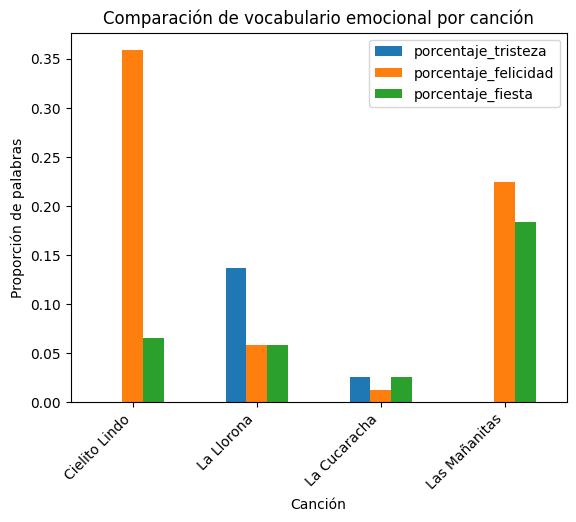

In [29]:
# Vocabulario por canción
df_plot = df_resultado.set_index("cancion")[["porcentaje_tristeza", "porcentaje_felicidad", "porcentaje_fiesta"]]
df_plot.plot(kind="bar")
plt.title("Comparación de vocabulario emocional por canción")
plt.xlabel("Canción")
plt.ylabel("Proporción de palabras")
plt.xticks(rotation=45, ha="right")
plt.show()

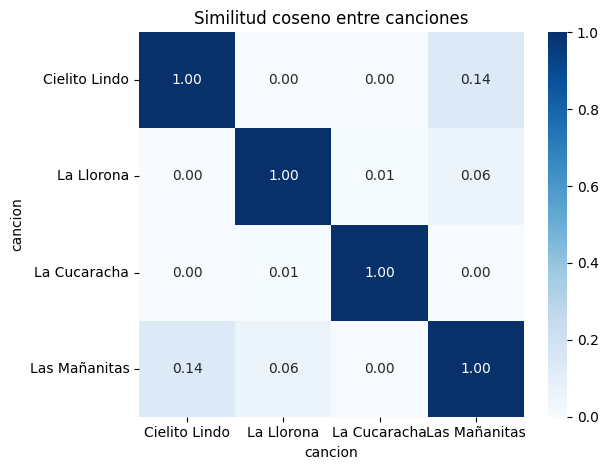

In [41]:
# Similitudes entre canciones (coseno)

df["texto_procesado"] = df["tokens"].apply(lambda x: " ".join(x)) # Formato
vectorizar = TfidfVectorizer() # Vectorizar
X = vectorizar.fit_transform(df["texto_procesado"]) # Texto a vector
matriz_similitud = cosine_similarity(X) # Similitud coseno

# DataFrame
df_similitud = pd.DataFrame(
    matriz_similitud,
    index=df["cancion"],
    columns=df["cancion"]
)

# Gráfico
plt.figure()
sns.heatmap(df_similitud, annot=True, fmt=".2f", cmap="Blues")
plt.title("Similitud coseno entre canciones")
plt.tight_layout()
plt.show()

# Blogs Científicos

In [43]:
national_geographic = """Las mujeres y las niñas desempeñan un papel fundamental en las comunidades científicas y tecnológicas y su participación debe fortalecerse, asegura la Organización de las Naciones Unidas (ONU).

A lo largo de la historia, muchas científicas han dedicado su vida a la investigación y han logrado importantes avances, reconoce el Alto Comisionado de las Naciones Unidas para los Refugiados (Acnur). Una buena ocasión para reconocer su labor es el Día de la Mejor, que se conmemora el 8 de marzo.

A continuación, 8 científicas destacadas de la historia, de acuerdo con Acnur:

1. Caroline Herschel
Nacida en Alemania, Caroline (1750-1848) era asistente de su hermano William, quien era astrónomo y construía telescopios. Mientras trabajaba con él, descubrió nuevas nebulosas y cúmulos de estrellas.

Entre sus aportes a la ciencia, Herschel fue la primera mujer en descubrir un cometa, la primera dama cuyo trabajo fue publicado por la sociedad científica Royal Society y la primera británica en obtener un salario por realizar trabajo científico, indica Acnur.

En 1783 esta científica descubrió tres nuevas nebulosas (nubes brumosas donde se forman las estrellas) y, entre 1786 y 1797, descubrió ocho cometas, agrega la NASA.


2. Ada Lovelace
Aunque vivió entre los años 1815 y 1852, esta mujer es considerada la primera programadora de ordenadores de la historia y la persona que inició el sistema informático que conocemos en la actualidad, señala el organismo de las Naciones Unidas.

Concretamente, desarrolla Acnur, Lovelace era colega de Charles Babbage (un matemático y científico británico) con quien trabajó en la calculadora denominada máquina analítica. Entre sus notas sobre este aparato se encontró el primer algoritmo destinado a ser procesado por una máquina.

En su honor, el Departamento de Defensa de Estados Unidos llamó “Ada” a un lenguaje de programación.


3. Marie Curie
Marie Curie (1867 – 1934) fue una física y química polaca pionera en el estudio de la radiación. Sus investigaciones la llevaron a descubrir dos elementos radiactivos: el radio y el polonio.

De acuerdo con ONU Mujeres, Curie sentó las bases para la ciencia nuclear moderna, desde los rayos X hasta la radioterapia para el tratamiento del cáncer.

Además, fundó un instituto de investigación médica en Varsovia e inventó unidades móviles de rayos X que ayudaron a más de un millón de soldados heridos en la Primera Guerra Mundial.

Por sus aportes recibió dos premios Nobel y se convirtió en la primera mujer en hacerse de este reconocimiento y en la primera persona en ganar dos premios Nobel en distintas ciencias (en Física en 1903 y en Química en 1911).


4. Lise Meitner
Fue una física sueca de origen austriaco que vivió entre los años 1878 y 1968. Junto con su compañero de investigación, Otto Hahn, trabajó en el estudio de elementos radiactivos.

Según Acnur, Meitner calculó la energía liberada en la fisión nuclear y acuñó dicho término. A pesar de su aporte, fue Hahn quien ganó un Premio Nobel por este descubrimiento, mientras que Meitner no fue tomada en consideración por el Comité del galardón.

5. Rosalind Franklin
Desde muy joven, Rosalind Franklin (1920-1958) supo que quería dedicarse a la ciencia y se doctoró en Química en la Universidad de Cambridge. Esta científica logró hacer una fotografía que mostraba la doble hélice del ADN, señala la organización Acnur.

“Otro investigador del mismo laboratorio, Maurice Wilkins, mostró la imagen a dos compañeros y juntos publicaron el descubrimiento en la revista Nature. En 1962, estos tres investigadores recibieron el Premio Nobel por el descubrimiento de la doble hélice del ADN, pero Franklin había fallecido cuatro años antes por cáncer de ovario”, explica el Alto Comisionado.
6. Margarita Salas
La científica española Margarita Salas (1938-2019) fue doctora en Biología y centró sus investigaciones en el campo de la biología molecular. Una de sus principales contribuciones a la ciencia fue el descubrimiento del ADN polimerasa, el responsable de la replicación del ADN.

7. Elizabeth Blackburn
Esta científica australiana nacida en 1948 es doctora en Biología Molecular. Blackburn descubrió la telomerasa, una enzima que alarga los telómeros, que son los extremos de los cromosomas, e influyen directamente en la vida de las células. Según Acnur, el organismo de las Naciones Unidas, sus investigaciones sobre la telomerasa contribuyen al estudio de las terapias contra el cáncer.

Gracias a la investigación de la telomerasa, esta australiana recibió el Premio Nobel de Fisiología o Medicina 2009 junto con sus colegas Carol Greider y Jack Szostak, según consta en la web del galardón internacional


8. Flora de Pablo
Por último, Acnur destaca la labor de Flor de Pablo (nacida en 1952 en España). Según la Asociación de Mujeres Investigadoras y Tecnólogas (Amit) de España, una organización que busca defender los intereses y la igualdad de derechos y oportunidades de las investigadoras y tecnólogas, ella es Licenciada en Medicina y Diplomada en Psicología.

Además, continúa Acnur, es doctora especializada en biología molecular y su investigación se centra en procesos de proliferación, diferenciación, competición y muerte de las células.

Flora de Pablo ha combinado su labor científica con la lucha por el reconocimiento del trabajo de las mujeres en la ciencia. Es socia fundadora de Amit y fue su primera presidenta (entre los años 2001 y 2007).
"""



bbva = """A lo largo del siglo XX, numerosas mujeres realizaron descubrimientos fundamentales en física, química, astronomía o genética sin recibir el reconocimiento merecido. En el Día Internacional de la Mujer y la Niña en la Ciencia, se recuerdan las historias de científicas cuyos trabajos transformaron el conocimiento y abrieron camino a nuevas generaciones.

No son pocos los obstáculos que han tenido que atravesar las visionarias mujeres pioneras en la ciencia. No solo la discriminación de género, también la competitividad desmedida o el arraigo de las jerarquías dentro del ámbito científico. Ejemplo de ello es el caso de Rosalind Franklin, injustamente marginada del reconocimiento por su contribución al descubrimiento de la estructura del ADN.

Es necesario recorre la historia científica del siglo XX para poner de manifiesto la presencia de importantes descubrimientos fruto del trabajo de las mujeres. Muchas de ellas, subestimada en su época.
Barreras históricas que enfrentaron las mujeres en la ciencia
Exclusión del acceso a universidades.
Falta de reconocimiento institucional.
Jerarquías académicas rígidas.
Exilio por motivos políticos o religiosos.
Apropiación del mérito científico.
Emmy Noether y el teorema que revolucionó la física
El teorema de Noether, que cumplió 100 años en 2015, fascinó a las grandes mentes del siglo XX porque revela la íntima conexión entre las simetrías de la naturaleza y la forma de las leyes fundamentales de la física. Sencillo y profundo, es un todoterreno de la física teórica, que puede aplicarse tanto a la teoría cuántica de campos como a los básicos problemas de mecánica clásica de bachillerato. Este teorema fue su primer trabajo al llegar al departamento de matemáticas de la Universidad de Gotinga en 1915, donde no podía impartir clases, porque Emmy Noether era una mujer.

Las barreras de género fueron una constante en su carrera. Para seguir los pasos de su padre, un gran matemático alemán, Emmy tuvo que asistir como oyente a las clases en la universidad, que a principios del siglo XX aún no aceptaba oficialmente a mujeres. Cuando por fin pudo licenciarse estuvo trabajando en el Instituto Matemático de Erlagen durante 7 años, sin recibir sueldo y sin que la reconocieran como profesora. En 1919, ya en Gotinga, por fin recibió la autorización para enseñar pero con un título no oficial de profesora ayudante. Fue lo más que consiguió, a pesar de liderar un equipo con prestigio mundial y de que sus discípulos sí fueron aceptados como investigadores y profesores titulares.

Emmy Noether hizo grandes aportaciones a un campo muy innovador de las matemáticas, el álgebra abstracta. Y cuando estos méritos empezaban a ser reconocidos fue expulsada de la universidad, porque era judía. Los nazis acababan de llegar al poder y Noether se exilió a EEUU en 1933, donde murió dos años más tarde. Einstein escribió un obituario en su honor en The New York Times, donde la definió como «la genio creativa de las matemáticas más significativa desde que comenzó la educación superior para las mujeres».

Cecilia Payne y el descubrimiento de la composición del Sol
La astrónoma que descubrió la composición del Sol también tuvo una carrera marcada por la discriminación de género, sobre todo en su Inglaterra natal. Allí estudió ciencias en la Universidad de Cambridge y pudo asistir a conferencias de grandes científicos pero no pudo licenciarse, porque Cambridge no daba títulos universitarios a mujeres (y no lo hizo hasta 1948). Cecilia Payne quería ser científica y para ello tuvo que emigrar en 1923 a Estados Unidos, donde empezaba a haber becas para atraer a las mujeres hacia la investigación en astronomía.

Payne consiguió una beca para hacer el doctorado en el Observatorio de Harvard, aunque el título se lo dio una universidad asociada, porque Harvard era aún exclusivamente masculina. De su tesis doctoral, presentada en 1925, se dijo entonces que “sin duda es la tesis más brillante que se ha escrito en astronomía”. Y eso que Henry Norris Russell, un colega que se la revisó, la convenció para que retirara de ella una conclusión importante: la novata Cecilia Payne proponía en su primer trabajo astronómico que el Sol estaba compuesto en un 99% por hidrógeno.

Era una idea revolucionaria, pues entonces el consenso científico asumía que nuestra estrella era de mayormente de hierro (un 65%), con una composición similar a la de la Tierra. Russell, como el resto de astrónomos, no se tomó muy en serio el atrevimiento de Payne hasta que años más tarde llegó a la misma conclusión por otro camino. Entonces él se atribuyó el mérito, aunque citó brevemente a Payne en su publicación científica, y durante muchos años se le reconoció como autor del descubrimiento.

Mientras tanto, Cecilia Payne siguió observando las estrellas, avanzando en el estudio de su evolución y de la estructura de nuestra galaxia, la Vía Láctea. Y también empezó a destacar en Harvard como una profesora sobresaliente y apasionada. Pero extraoficialmente, porque en teoría solo era una asistente técnica y sus cursos no estaban en el catálogo oficial. Tuvieron que pasar 15 años hasta que se le reconoció como astrónoma y 31 años hasta que en 1956 fue la primera mujer aceptada como profesora titular en la principal facultad de la Universidad de Harvard, donde también fue la primera mujer que dirigió un departamento. Su trayectoria académica abrió camino e inspiró a grandes científicas que vinieron después.

Marthe Gautier y el origen genético del síndrome de Down
Marthe Gautier siguió luchando hasta su muerte porque se reconozca su papel en el descubrimiento de la causa del síndrome de Down. El tanto se lo apuntó Jérôme Lejeune, otro pediatra de su equipo en el Hospital Trousseau de Paris. Fue este grupo el que sin duda descubrió en 1959 que el síndrome de Down lo provoca un trantorno genético, por el que los afectados tienen un cromosoma más de los 46 que caracterizan el genoma humano.

Lejeune figura como primer autor en el artículo científico que difundió el descubrimiento y Gautier aparece en segundo lugar. A partir de ahí Lejeune continuó su carrera como genetista, estudiando otras anomalías en los cromosomas. Y creó una fundación, que desde 1970 comenzó a promoverlo como único autor del descubrimiento. Jérôme Lejeune (1926–1994) aspiraba a recibir el premio Nobel y creía que no se lo concedieron principalmente por su activa posición como antiabortista.

La versión de Gautier es diferente. La investigadora francesa sostiene que fue ella quien apuntó hacia la existencia de un cromosoma número 47, pero no pudo encontrarlo porque su microscopio no era suficientemente potente. Así que le pasó sus muestras a Lejeune, quien pudo ver el cromosoma extra y fotografiarlo en un laboratorio mejor equipado. Según Gautier, su colega ya se atribuyó el mérito del descubrimiento en un congreso celebrado en Montreal (Canadá) en 1958 y la dejó completamente de lado en la redacción del artículo publicado en 1959. La controversia sigue viva en los tribunales. En enero de 2014, Marthe Gautier iba a recibir en un congreso el reconocimiento de la Federación Francesa de Genética Humana pero la Fundación Lejeune acudió a los tribunales y la intervención de Gautier fue cancelada.

Lise Meitner y la interpretación de la fisión nuclear
Por encima de Rosalind Franklin, la física austríaca Lise Meitner es el caso más evidente de descubrimiento científico realizado por una mujer e ignorado por el comité de los premios Nobel. Fue ella quien se dio cuenta en 1938 de que se había producido una fisión nuclear en los experimentos realizados por sus colegas en el laboratorio. Y fue uno de ellos, Otto Hahn, quien recibió el premio Nobel de Química en 1944 por el descubrimiento.

A Lise Meitner le faltó el reconocimiento oficial, pero no el compañerismo: Otto Hahn la nombró nueve veces en su discurso de aceptación del Nobel. Habían trabajado juntos durante tres décadas hasta que, en el año de su gran descubrimiento común, Meitner tuvo que huir de la Alemania nazi.

Otto Hahn le ayudó a escapar hacia Suecia y Lise Meitner siguió colaborando con él desde su exilio. Meitner siempre reconoció el mérito del experimento de Hahn, pero fue ella quien primero supo interpretarlo correctamente con un artículo publicado en la revista Nature, donde apareció por primera vez el término “fisión nuclear”, y apuntó la posibilidad de una reacción en cadena. Aquello hizo reaccionar a los EEUU, que intentaron reclutarte sin éxito para el proyecto Manhattan: «No quiero tener nada que ver con una bomba», declaró.

Jocelyn Bell: la astrónoma que descubrió los púlsares y no recibió el reconocimiento
La astrónoma norirlandesa Jocelyn Bell nunca ha querido entrar en la polémica de su exclusión del Nobel de Física en 1974. Le resta importancia y no lo ve como una discriminación de género, sino como una cuestión de jerarquía entre un estudiante y los investigadores que lo supervisan, «que deben llevarse el crédito de los éxitos y fracasos, salvo en casos excepcionales. Y este no lo es».

Como estudiante de doctorado, Bell ayudó a construir un radiotelescopio en la Universidad de Cambridge y comenzó a estudiar las señales que captaba del espacio profundo. Revisaba metros y metros de papel impreso con gráficas, hasta que un día de 1967 descubrió unas extrañas marcas, demasiado rápidas y demasiado regulares. Reconoció que allí había algo importante, aunque no supo lo que era. Ella y su director de tesis, Anthony Hewish, denominaron a aquella señal LGM (siglas de Little Green Men, “hombrecillos verdes” en inglés), bromeando con la posibilidad de que fueran señales enviadas por extraterrestres.

Más adelante se comprendió que aquellas extrañas señales eran emitidas por una estrella de neutrones girando a gran velocidad, que fue denominada púlsar. El comité de los Nobel reconoció a Hewish por el descubrimiento de los púlsares pero ignoró a Jocelyn Bell, lo que desató la reacción airada de eminentes científicos en la primera ocasión en que la Academia Sueca premiaba un trabajo de astronomía. Para uno de ellos, Iosif Shklovsky, Bell había realizado «el mayor descubrimiento astronómico del siglo XX».

Rosalind Franklin: la clave en el descubrimiento de la estructura del ADN
Lo único que está claro en el caso de Rosalind Franklin es que no se le negó el premio Nobel por discriminación de género. Ella murió en 1958, cuatro años antes de que la Academia Sueca premiara a su colega Maurice Wilkins y a sus rivales James Watson y Francis Crick, por el descubrimiento de la estructura molecular del ADN. Y el nobel no puede concederse a título póstumo.

Cuando Franklin murió, a los 37 años de edad, se le reconoció el mérito de sus investigaciones sobre las estructuras del carbón y de los virus. Pero en su obituario no se mencionó nada del ADN. En gran parte porque hasta después de su muerte la estructura del ADN (que ayudó a descifrar en 1953) no se consideró completamente probada; ni siquiera se reconocía la importancia biológica de la que hoy se considera unánimemente como “la molécula de la vida”.

Así que nunca sabremos si Rosalind Franklin hubiera compartido el Nobel de Medicina en 1962. Pero lo que es injusto es que ni Watson ni Crick ni Wilkins la mencionaran en sus discursos de aceptación, porque la famosa imagen de difracción de rayos X obtenida por Franklin (la llamada “Fotografía 51”) les dio a ellos una pista crucial sobre la correcta estructura en doble hélice del ADN.

Solo años más tarde, en su relato autobiográfico “La doble hélice” (1968), Watson empezó a reconocer la contribución de Franklin a su descubrimiento, aunque lo hizo en medio de comentarios negativos sobre ella. Se ha escrito mucho sobre esa polémica. Si aquel fue un caso de sexismo, de intensa competitividad, de choque de personalidades entre Watson y Franklin… o incluso de antisemitismo soterrado (ella era judía).

También se ha discutido mucho si la contribución de Franklin merecería compartir aquel premio Nobel. Pero lo que es mucho menos conocido es que ella hubiera merecido aún más un segundo premio, el Nobel de Química de 1982 otorgado a su discípulo Aaron Klug “por el desarrollo de los métodos cristalográficos para descifrar la estructura de los complejos proteínicos de los ácidos nucleicos”. Es muy probable que, si ella hubiera vivido suficiente, ambos hubieran compartido ese premio, que reconoció el trabajo iniciado por Franklin y continuado por Klug.Sin embargo Rosalind Franklin murió muy joven, por un cáncer de ovario probablemente causado por su trabajo sin protegerse de los rayos X, que nos revelaron el secreto de la vida, pero que pudieron dañar su propio ADN y desencadenar el cáncer.

Henrietta Swan Leavitt: la astrónoma que permitió medir el universo
A comienzos del siglo XX, cuando las mujeres aún tenían prohibido trabajar con telescopios, la astrónoma americana Henrietta Swan Leavitt descubrió una ley en las estrellas que permitiría calcular por primera vez grandes distancias en el Universo. Lo hizo tras revisar miles de fotografías de las estrellas que forman dos galaxias enanas conocidas como Nubes de Magallanes. En aquellas instantáneas encontró que un tipo de estrellas, las Cefeidas, mostraban una relación entre luminosidad y parpadeo.

En 1893 Leavitt empezó a trabajar en el grupo de computadoras humanas del Observatorio de la Universidad de Harvard, mujeres contratadas para realizar monótonas tareas como examinar fotografías de estrellas o hacer cálculos matemáticos. En 1908 publicó su descubrimiento sobre las Cefeidas en el Anuario del Observatorio, donde explicaba que estas estrellas parecían seguir un patrón, las más luminosas parpadeaban más lentamente. En 1912 enunció la relación periodo-luminosidad o Ley de Leavitt, que determina la relación directa entre la luminosidad media de las Cefeidas y el periodo de su parpadeo. La Ley de Leavitt abrió el camino para medir la distancia a la que están muchas galaxias, y fue imprescindible para que en 1918 Edwin Hubble calculase el tamaño de la Vía Láctea.

Leavitt trabajó en el Observatorio de Harvard hasta su muerte a los 53 años. Durante su silenciosa carrera (era sorda) descubrió cerca de 2500 estrellas. Como muchas otras científicas del siglo XX, Leavitt no recibió reconocimiento en vida. Hoy se recuerda su enorme contribución a la astronomía con un cráter en la Luna que lleva su nombre y con el asteroide 5383 Leavitt.

"""

In [45]:
df = pd.DataFrame({
    "fuente": [
        "National Geographic",
        "BBVA"
    ],
    "tema": [
        "Científicas que hicieron historia",
        "Día Internacional de la Mujer"
    ],
    "texto": [
        national_geographic,
        bbva
    ]
})

df

,fuente,tema,texto
0,National Geographic,Científicas que hicieron historia,Las mujeres y las niñas desempeñan un papel fu...
1,BBVA,Día Internacional de la Mujer,"A lo largo del siglo XX, numerosas mujeres rea..."


In [48]:
df["tokens"] = df["texto"].apply(limpiar_lematizar)
df["num_palabras"] = df["tokens"].apply(len) # Contar palabras
df["palabras_unicas"] = df["tokens"].apply(lambda x: len(set(x))) # Contar palabras únicas
df["diversidad_lexica"] = df["palabras_unicas"] / df["num_palabras"] # Variación del vocabulario

df[["fuente", "tema", "num_palabras", "palabras_unicas", "diversidad_lexica"]]

,fuente,tema,num_palabras,palabras_unicas,diversidad_lexica
0,National Geographic,Científicas que hicieron historia,411,264,0.642336
1,BBVA,Día Internacional de la Mujer,1027,572,0.556962


In [50]:
# Impresión de palabras frecuentes
for i, fila in df.iterrows():
    print("\n", fila["fuente"])
    display(palabras_frecuentes(fila["tokens"], top = 3))


 National Geographic


,palabra,frecuencia
0,acnur,9
1,investigación,8
2,mujer,7



 BBVA


,palabra,frecuencia
0,descubrimiento,18
1,mujer,15
2,franklin,12


In [ ]:
# Vocabulario por canción
df_plot = df_resultado.set_index("cancion")[["porcentaje_tristeza", "porcentaje_felicidad", "porcentaje_fiesta"]]
df_plot.plot(kind="bar")
plt.title("Comparación de vocabulario emocional por canción")
plt.xlabel("Canción")
plt.ylabel("Proporción de palabras")
plt.xticks(rotation=45, ha="right")
plt.show()

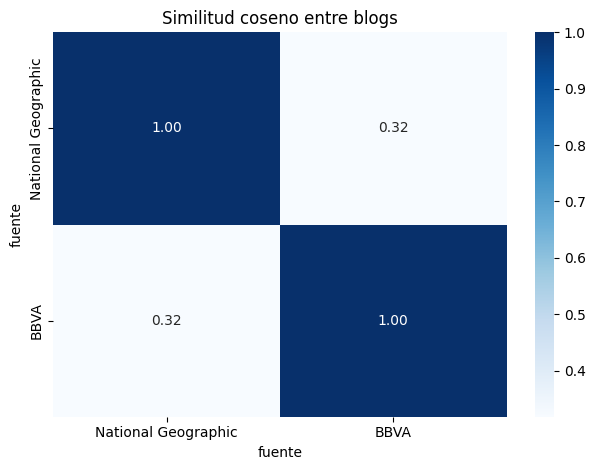

In [51]:
# Similitudes (coseno)

df["texto_procesado"] = df["tokens"].apply(lambda x: " ".join(x)) # Formato
vectorizar = TfidfVectorizer() # Vectorizar
X = vectorizar.fit_transform(df["texto_procesado"]) # Texto a vector
matriz_similitud = cosine_similarity(X) # Similitud coseno

# DataFrame
df_similitud = pd.DataFrame(
    matriz_similitud,
    index=df["fuente"],
    columns=df["fuente"]
)

# Gráfico
plt.figure()
sns.heatmap(df_similitud, annot=True, fmt=".2f", cmap="Blues")
plt.title("Similitud coseno entre blogs")
plt.tight_layout()
plt.show()

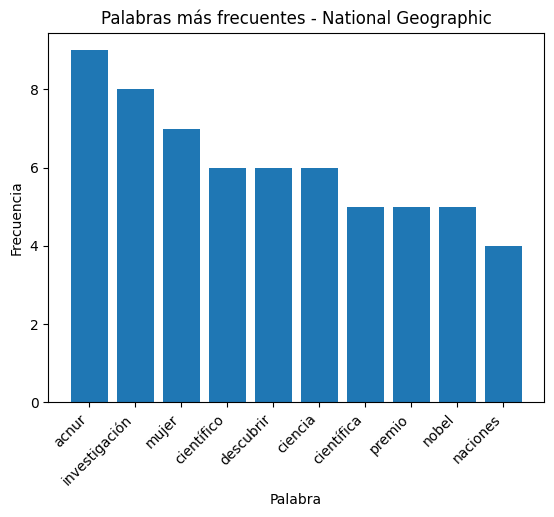

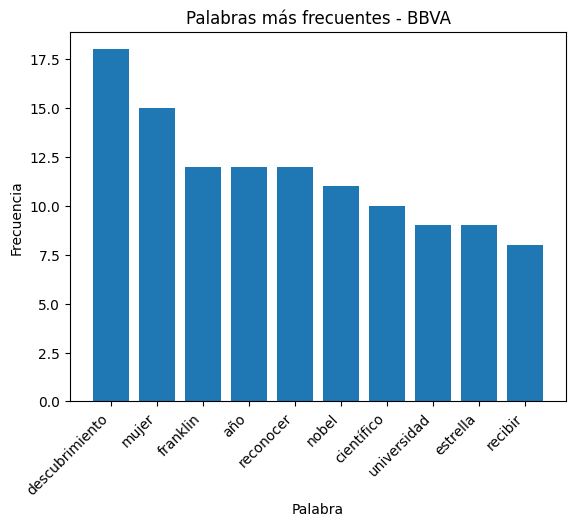

In [54]:
for i, fila in df.iterrows():
    freq = palabras_frecuentes(fila["tokens"], top=10)

    plt.figure()
    plt.bar(freq["palabra"], freq["frecuencia"])
    plt.title(f"Palabras más frecuentes - {fila['fuente']}")
    plt.xlabel("Palabra")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")
    plt.show()

In [2]:
import spacy

nlp = spacy.load("es_core_news_sm")

In [3]:
import pandas as pd

letra_cielito_lindo = """De la Sierra Morena, cielito lindo, vienen bajando Un par de ojitos negros, cielito lindo, de contrabando De la Sierra Morena, cielito lindo, vienen bajando Un par de ojitos negros, cielito lindo, de contrabando Ay, ay, ay, ay Canta y no llores Porque cantando se alegran, cielito lindo, los corazones Ay, ay, ay, ay Canta y no llores Porque cantando se alegran, cielito lindo, los corazones Ese lunar que tienes, cielito lindo, junto a la boca No se lo des a nadie, cielito lindo, que a mí me toca Ese lunar que tienes, cielito lindo, junto a la boca No se lo des a nadie, cielito lindo, que a mí me toca Ay, ay, ay, ay Canta y no llores Porque cantando se alegran, cielito lindo, los corazones Ay, ay, ay, ay Canta y no llores Porque cantando se alegran, cielito lindo, los corazones Siempre que te enamores Mira primero, mira primero Donde pones los ojos, cielito lindo No llores luego Ay, ay, ay, ay Canta y no llores Porque cantando se alegran, cielito lindo, los corazones Ay, ay, ay, ay Canta y no llores Porque cantando se alegran, cielito lindo, los corazones"""

letra_llorona = """No sé qué tienen las flores, llorona Las flores del campo santo No sé qué tienen las flores, llorona Las flores del campo santo Que cuando las mueve el viento, llorona Parece que están llorando Que cuando las mueve el viento, llorona Parece que están llorando Ay de mí, llorona Llorona, tú eres mi chunca Ay de mí, llorona Llorona, tú eres mi chunca Me quitarán de quererte, llorona Pero, de olvidarte, nunca Me quitarán de quererte, llorona Pero, de olvidarte, nunca A un Santo Cristo de fierro, llorona Mis penas, le conté yo A un Santo Cristo de fierro, llorona Mis penas, le conté yo Cuáles no serían mis penas, llorona Que el Santo Cristo lloró Cuáles no serían mis penas, llorona Que el Santo Cristo lloró Ay de mí, llorona Llorona de un campo lirio Ay de mí, llorona Llorona de un campo lirio El que no sabe de amores, llorona No sabe lo que es martirio El que no sabe de amores, llorona No sabe lo que es martirio Dos besos llevo en el alma, llorona Que no se apartan de mí Dos besos llevo en el alma, llorona Que no se apartan de mí El último de mi madre, llorona Y el primero que te di El último de mi madre, llorona Y el primero que te di Ay de mí, llorona Llorona, llévame al río Ay de mí, llorona Llorona, llévame al río Tápame con tu rebozo, llorona Porque me muero de frío Tápame con tu rebozo, llorona Porque me muero de frío"""

letra_cucaracha = """La cucaracha, la cucaracha Ya no puede caminar Porque no tiene, porque le falta Marihuana que fumar La cucaracha, la cucaracha Ya no puede caminar Porque no tiene, porque le falta Marihuana que fumar Con las barbas de Carranza Voy a hacer una toquilla Pa' ponérsela al sombrero Del señor Francisco Villa Con las barbas de Carranza Voy a hacer una toquilla Pa' ponérsela al sombrero Del señor Francisco Villa La cucaracha, la cucaracha Ya no puede caminar Porque no tiene, porque le falta Marihuana que fumar Qué bonita cucaracha Para echarme una bailada Empezando por la noche Hasta ahí en la madrugada Qué bonita cucaracha Para echarme una bailada Empezando por la noche Hasta ahí en la madrugada La cucaracha, la cucaracha Ya no puede caminar Porque no tiene, porque le falta Marihuana que fumar Ya murió la cucaracha Ya la llevan a enterrar Entre cuatro zopilotes Y uno que otro gavilán Ya murió la cucaracha Ya la llevan a enterrar Entre cuatro zopilotes Y uno que otro gavilán La cucaracha, la cucaracha Ya no puede caminar Porque no tiene, porque le falta Marihuana que fumar La cucaracha, la cucaracha Ya no puede caminar Porque no tiene, porque le falta Marihuana que fumar"""

letra_mananitas = """Estas son las mañanitas Que cantaba el rey David Hoy por ser día de tu santo Te las cantamos aquí Despierta, mi bien, despierta Mira que ya amaneció Ya los pajaritos cantan La Luna ya se metió Qué linda está la mañana En que vengo a saludarte Venimos todos con gusto Y placer a felicitarte El día en que tú naciste Nacieron todas las flores En la pila del bautismo Cantaron los Ruiseñores Ya viene amaneciendo Ya la luz del día nos dio Levántate de mañana Mira que ya amaneció Si yo pudiera bajarte Las estrellas y un lucero Para poder demostrarte Lo mucho que yo te quiero Con jazmines y flores Este día quiero adornar Hoy, por ser día de tu santo Te venimos a cantar"""

df = pd.DataFrame({
    "cancion": [
        "Cielito Lindo",
        "La Llorona",
        "La Cucaracha",
        "Las Mañanitas"
    ],
    "tono_esperado": [
        "Alegre / romántica",
        "Triste / nostálgica",
        "Humorística / satírica",
        "Celebración / cariño"
    ],
    "letra": [
        letra_cielito_lindo,
        letra_llorona,
        letra_cucaracha,
        letra_mananitas
    ]
})

df

,cancion,tono_esperado,letra
0,Cielito Lindo,Alegre / romántica,"De la Sierra Morena, cielito lindo, vienen baj..."
1,La Llorona,Triste / nostálgica,"No sé qué tienen las flores, llorona Las flore..."
2,La Cucaracha,Humorística / satírica,"La cucaracha, la cucaracha Ya no puede caminar..."
3,Las Mañanitas,Celebración / cariño,Estas son las mañanitas Que cantaba el rey Dav...


In [4]:
import re
import spacy
from collections import Counter

nlp = spacy.load("es_core_news_sm")

def limpiar_lematizar(texto):
    texto = texto.lower()
    texto = re.sub(r"\d+", " ", texto)
    texto = re.sub(r"[^\w\sáéíóúñü]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    doc = nlp(texto)

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.is_alpha
        and len(token.text) > 2
    ]

    return tokens

df["tokens"] = df["letra"].apply(limpiar_lematizar)

df["num_palabras"] = df["tokens"].apply(len)
df["palabras_unicas"] = df["tokens"].apply(lambda x: len(set(x)))
df["diversidad_lexica"] = df["palabras_unicas"] / df["num_palabras"]

df[["cancion", "tono_esperado", "num_palabras", "palabras_unicas", "diversidad_lexica"]]

,cancion,tono_esperado,num_palabras,palabras_unicas,diversidad_lexica
0,Cielito Lindo,Alegre / romántica,92,24,0.260870
1,La Llorona,Triste / nostálgica,102,32,0.313725
2,La Cucaracha,Humorística / satírica,78,25,0.320513
3,Las Mañanitas,Celebración / cariño,49,35,0.714286


In [5]:
def palabras_frecuentes(tokens, top=15):
    conteo = Counter(tokens)
    return pd.DataFrame(conteo.most_common(top), columns=["palabra", "frecuencia"])

for i, fila in df.iterrows():
    print("\n", fila["cancion"])
    display(palabras_frecuentes(fila["tokens"], top=15))


 Cielito Lindo


,palabra,frecuencia
0,cielito,15
1,lindo,15
2,llor,7
3,canta,6
4,cantar,6
5,alegrar,6
6,corazón,6
7,sierra,2
8,morena,2
9,venir,2



 La Llorona


,palabra,frecuencia
0,lloronar,16
1,llorona,10
2,santo,6
3,flor,4
4,campo,4
5,llorar,4
6,llorón,4
7,cristo,4
8,pena,4
9,mover,2



 La Cucaracha


,palabra,frecuencia
0,cucaracha,16
1,caminar,6
2,faltar,6
3,marihuán,6
4,fumar,6
5,barba,2
6,carranza,2
7,toquilla,2
8,ponérsela,2
9,sombrero,2



 Las Mañanitas


,palabra,frecuencia
0,cantar,4
1,venir,4
2,amanecer,3
3,santo,2
4,despertar,2
5,mira,2
6,mañana,2
7,flor,2
8,querer,2
9,mañanita,1


In [6]:
palabras_tristeza = {
    "llorar", "llanto", "pena", "dolor", "triste", "tristeza",
    "martirio", "muero", "morir", "muerte", "frío", "olvidar"
}

palabras_felicidad = {
    "cantar", "alegrar", "alegría", "lindo", "bonito", "corazón",
    "felicitar", "placer", "gusto", "flor", "querer", "amor"
}

palabras_fiesta = {
    "bailar", "bailada", "cantar", "mañanita", "cumpleaños",
    "santo", "felicitar", "gusto", "placer"
}

def contar_emociones(tokens):
    total = len(tokens)

    tristeza = sum(1 for t in tokens if t in palabras_tristeza)
    felicidad = sum(1 for t in tokens if t in palabras_felicidad)
    fiesta = sum(1 for t in tokens if t in palabras_fiesta)

    return pd.Series({
        "conteo_tristeza": tristeza,
        "conteo_felicidad": felicidad,
        "conteo_fiesta": fiesta,
        "pct_tristeza": tristeza / total if total > 0 else 0,
        "pct_felicidad": felicidad / total if total > 0 else 0,
        "pct_fiesta": fiesta / total if total > 0 else 0
    })

df_emociones = df["tokens"].apply(contar_emociones)

df_resultado = pd.concat([df, df_emociones], axis=1)

df_resultado[[
    "cancion",
    "tono_esperado",
    "num_palabras",
    "palabras_unicas",
    "diversidad_lexica",
    "conteo_tristeza",
    "conteo_felicidad",
    "conteo_fiesta",
    "pct_tristeza",
    "pct_felicidad",
    "pct_fiesta"
]]

,cancion,tono_esperado,num_palabras,palabras_unicas,diversidad_lexica,conteo_tristeza,conteo_felicidad,conteo_fiesta,pct_tristeza,pct_felicidad,pct_fiesta
0,Cielito Lindo,Alegre / romántica,92,24,0.260870,0.0,33.0,6.0,0.000000,0.358696,0.065217
1,La Llorona,Triste / nostálgica,102,32,0.313725,14.0,6.0,6.0,0.137255,0.058824,0.058824
2,La Cucaracha,Humorística / satírica,78,25,0.320513,2.0,1.0,2.0,0.025641,0.012821,0.025641
3,Las Mañanitas,Celebración / cariño,49,35,0.714286,0.0,11.0,9.0,0.000000,0.224490,0.183673


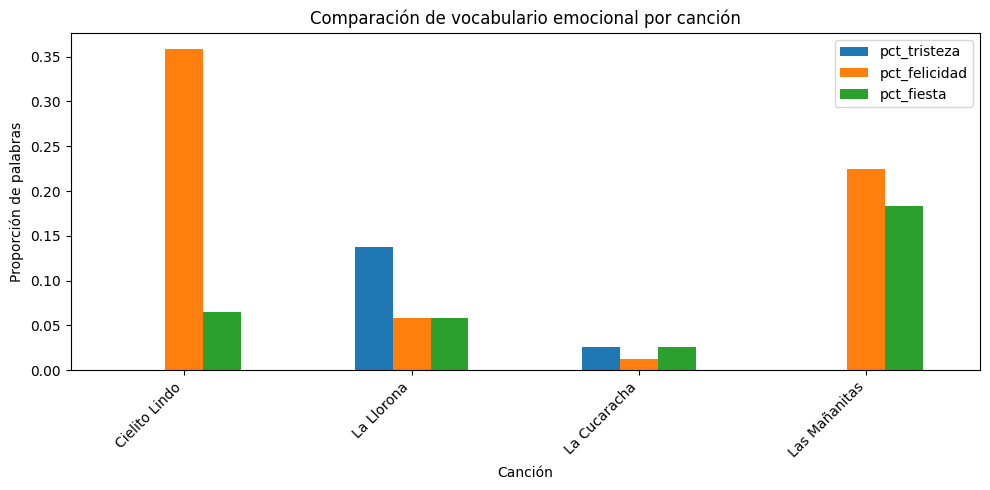

In [7]:
import matplotlib.pyplot as plt

df_plot = df_resultado.set_index("cancion")[
    ["pct_tristeza", "pct_felicidad", "pct_fiesta"]
]

df_plot.plot(kind="bar", figsize=(10, 5))

plt.title("Comparación de vocabulario emocional por canción")
plt.xlabel("Canción")
plt.ylabel("Proporción de palabras")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df["texto_procesado"] = df["tokens"].apply(lambda x: " ".join(x))

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["texto_procesado"])

matriz_similitud = cosine_similarity(X)

df_similitud = pd.DataFrame(
    matriz_similitud,
    index=df["cancion"],
    columns=df["cancion"]
)

df_similitud

cancion,Cielito Lindo,La Llorona,La Cucaracha,Las Mañanitas
cancion,,,,
Cielito Lindo,1.00000,0.000000,0.000000,0.137080
La Llorona,0.00000,1.000000,0.009665,0.060612
La Cucaracha,0.00000,0.009665,1.000000,0.000000
Las Mañanitas,0.13708,0.060612,0.000000,1.000000


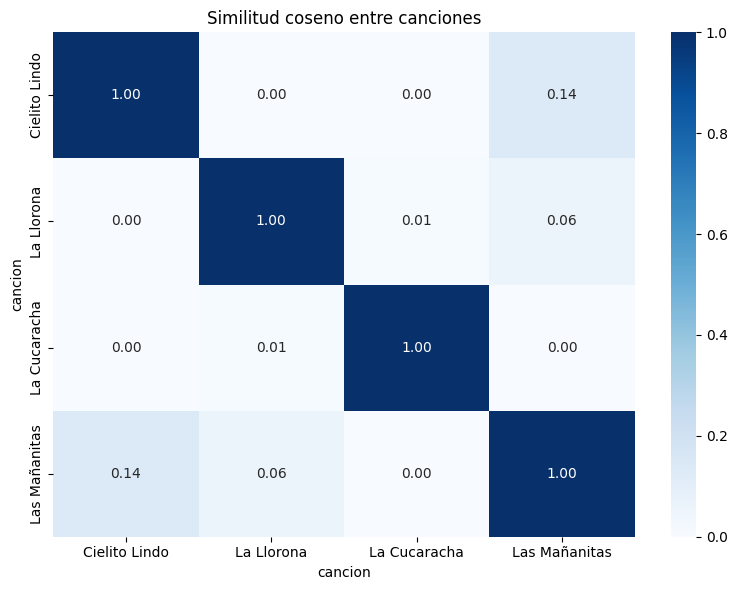

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(df_similitud, annot=True, fmt=".2f", cmap="Blues")
plt.title("Similitud coseno entre canciones")
plt.tight_layout()
plt.show()

In [10]:
import re
import spacy

nlp = spacy.load("es_core_news_sm")

def limpiar_lematizar(texto):
    texto = texto.lower()
    texto = re.sub(r"\d+", " ", texto)
    texto = re.sub(r"[^\w\sáéíóúñü]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    doc = nlp(texto)

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.is_alpha
        and len(token.text) > 2
    ]

    return tokens

df["tokens"] = df["letra"].apply(limpiar_lematizar)

df[["cancion", "tokens"]]

,cancion,tokens
0,Cielito Lindo,"[sierra, morena, cielito, lindo, venir, bajar,..."
1,La Llorona,"[flor, lloronar, flor, campo, santo, flor, llo..."
2,La Cucaracha,"[cucaracha, cucaracha, caminar, faltar, marihu..."
3,Las Mañanitas,"[mañanita, cantar, rey, david, santo, cantamos..."


In [11]:
df["num_palabras"] = df["tokens"].apply(len)
df["palabras_unicas"] = df["tokens"].apply(lambda x: len(set(x)))
df["diversidad_lexica"] = df["palabras_unicas"] / df["num_palabras"]

df[["cancion", "tono_esperado", "num_palabras", "palabras_unicas", "diversidad_lexica"]]

,cancion,tono_esperado,num_palabras,palabras_unicas,diversidad_lexica
0,Cielito Lindo,Alegre / romántica,92,24,0.260870
1,La Llorona,Triste / nostálgica,102,32,0.313725
2,La Cucaracha,Humorística / satírica,78,25,0.320513
3,Las Mañanitas,Celebración / cariño,49,35,0.714286


In [12]:
def contar_emociones_flexible(tokens):
    total = len(tokens)

    tristeza = sum(
        1 for t in tokens
        if t.startswith(("llor", "pen", "dolor", "trist", "martir", "mor", "frí", "olvid"))
    )

    felicidad = sum(
        1 for t in tokens
        if t.startswith(("cant", "alegr", "lind", "bonit", "corazón", "felicit", "placer", "gust", "flor", "quer", "amor"))
    )

    fiesta = sum(
        1 for t in tokens
        if t.startswith(("bail", "mañanit", "cumple", "santo", "felicit", "gust", "placer", "cant"))
    )

    return pd.Series({
        "conteo_tristeza": tristeza,
        "conteo_felicidad": felicidad,
        "conteo_fiesta": fiesta,
        "pct_tristeza": tristeza / total if total > 0 else 0,
        "pct_felicidad": felicidad / total if total > 0 else 0,
        "pct_fiesta": fiesta / total if total > 0 else 0
    })

df_emociones = df["tokens"].apply(contar_emociones_flexible)
df_resultado = pd.concat([df, df_emociones], axis=1)

df_resultado[[
    "cancion",
    "tono_esperado",
    "num_palabras",
    "palabras_unicas",
    "diversidad_lexica",
    "conteo_tristeza",
    "conteo_felicidad",
    "conteo_fiesta",
    "pct_tristeza",
    "pct_felicidad",
    "pct_fiesta"
]]

,cancion,tono_esperado,num_palabras,palabras_unicas,diversidad_lexica,conteo_tristeza,conteo_felicidad,conteo_fiesta,pct_tristeza,pct_felicidad,pct_fiesta
0,Cielito Lindo,Alegre / romántica,92,24,0.260870,9.0,39.0,12.0,0.097826,0.423913,0.130435
1,La Llorona,Triste / nostálgica,102,32,0.313725,46.0,8.0,6.0,0.450980,0.078431,0.058824
2,La Cucaracha,Humorística / satírica,78,25,0.320513,2.0,2.0,2.0,0.025641,0.025641,0.025641
3,Las Mañanitas,Celebración / cariño,49,35,0.714286,0.0,13.0,11.0,0.000000,0.265306,0.224490


In [13]:
from nltk import ngrams

def obtener_ngramas(tokens, n=2, top=10):
    lista_ngramas = list(ngrams(tokens, n))
    conteo = Counter(lista_ngramas)

    df_ngramas = pd.DataFrame(
        conteo.most_common(top),
        columns=["ngrama", "frecuencia"]
    )

    df_ngramas["ngrama"] = df_ngramas["ngrama"].apply(lambda x: " ".join(x))

    return df_ngramas

for i, fila in df.iterrows():
    print("\n", fila["cancion"])
    display(obtener_ngramas(fila["tokens"], n=2, top=10))


 Cielito Lindo


,ngrama,frecuencia
0,cielito lindo,15
1,canta llor,6
2,llor cantar,6
3,cantar alegrar,6
4,alegrar cielito,6
5,lindo corazón,6
6,corazón canta,3
7,sierra morena,2
8,morena cielito,2
9,lindo venir,2



 La Llorona


,ngrama,frecuencia
0,santo cristo,4
1,lloronar llorona,4
2,flor lloronar,2
3,lloronar flor,2
4,flor campo,2
5,campo santo,2
6,mover viento,2
7,viento llorona,2
8,llorona llorar,2
9,llorar lloronar,2



 La Cucaracha


,ngrama,frecuencia
0,cucaracha cucaracha,6
1,cucaracha caminar,6
2,caminar faltar,6
3,faltar marihuán,6
4,marihuán fumar,6
5,fumar cucaracha,2
6,barba carranza,2
7,carranza toquilla,2
8,toquilla ponérsela,2
9,ponérsela sombrero,2



 Las Mañanitas


,ngrama,frecuencia
0,mira amanecer,2
1,mañanita cantar,1
2,cantar rey,1
3,rey david,1
4,david santo,1
5,santo cantamos,1
6,cantamos despertar,1
7,despertar despertar,1
8,despertar mira,1
9,amanecer pajarito,1


In [34]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

urls = {
    "National Geographic": "https://www.nationalgeographicla.com/ciencia/2023/02/mujeres-en-la-ciencia-8-cientificas-que-hicieron-historia",
    "UNESCO": "https://www.unesco.org/es/virtual-science-museum/women-science",
    "BBVA": "https://www.bbva.com/es/sostenibilidad/mujeres-cientificas-olvidadas-de-rosalind-franklin-a-la-descubridora-del-sindrome-de-down/"
}

def extraer_texto_web(url):
    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    # Eliminar cosas que no sirven para el análisis
    for tag in soup(["script", "style", "nav", "footer", "header", "aside"]):
        tag.decompose()

    texto = soup.get_text(separator=" ")
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

datos = []

for fuente, url in urls.items():
    texto = extraer_texto_web(url)

    datos.append({
        "fuente": fuente,
        "url": url,
        "texto": texto
    })

df_web = pd.DataFrame(datos)

df_web[["fuente", "url", "texto"]]

,fuente,url,texto
0,National Geographic,https://www.nationalgeographicla.com/ciencia/2...,Mujeres en la ciencia: 8 cientÃ­ficas que hici...
1,UNESCO,https://www.unesco.org/es/virtual-science-muse...,Please enable JavaScript to view the page cont...
2,BBVA,https://www.bbva.com/es/sostenibilidad/mujeres...,Mujeres en la ciencia: pioneras invisibilizada...


In [35]:
df_web["num_caracteres"] = df_web["texto"].apply(len)

df_web[["fuente", "num_caracteres"]]

,fuente,num_caracteres
0,National Geographic,7310
1,UNESCO,310
2,BBVA,21213


In [36]:
for i, fila in df_web.iterrows():
    print("\n", fila["fuente"])
    print(fila["texto"][:1000])
    print("-" * 100)


 National Geographic
Mujeres en la ciencia: 8 cientÃ­ficas que hicieron historia | National Geographic | National Geographic Compartir Ciencia Mujeres en la ciencia: 8 cientÃ­ficas que hicieron historia En el DÃ­a Internacional de la Mujer, aprende sobre algunas de las cientÃ­ficas que dejaron una marca indeleble en la historia gracias a sus aportes. Retrato de Lise Meitner, fÃ­sica que descubriÃ³ que los nÃºcleos atÃ³micos se pueden dividir por la mitad: un primer paso en la eventual creaciÃ³n de la bomba atÃ³mica. Ilustrado por Lauren Brevner Por RedacciÃ³n National Geographic Publicado 7 mar 2025, 10:30 GMT-3 , Actualizado 4 mar 2026, 08:44 GMT-3 Las mujeres y las niÃ±as desempeÃ±an un papel fundamental en las comunidades cientÃ­ficas y tecnolÃ³gicas y su participaciÃ³n debe fortalecerse, asegura la OrganizaciÃ³n de las Naciones Unidas (ONU). A lo largo de la historia, muchas cientÃ­ficas han dedicado su vida a la investigaciÃ³n y han logrado importantes avances , reconoce el Alto 

In [17]:
import pandas as pd

national_geographic = """Las mujeres y las niñas desempeñan un papel fundamental en las comunidades científicas y tecnológicas y su participación debe fortalecerse, asegura la Organización de las Naciones Unidas (ONU).

A lo largo de la historia, muchas científicas han dedicado su vida a la investigación y han logrado importantes avances, reconoce el Alto Comisionado de las Naciones Unidas para los Refugiados (Acnur). Una buena ocasión para reconocer su labor es el Día de la Mejor, que se conmemora el 8 de marzo.

A continuación, 8 científicas destacadas de la historia, de acuerdo con Acnur:

1. Caroline Herschel
Nacida en Alemania, Caroline (1750-1848) era asistente de su hermano William, quien era astrónomo y construía telescopios. Mientras trabajaba con él, descubrió nuevas nebulosas y cúmulos de estrellas.

Entre sus aportes a la ciencia, Herschel fue la primera mujer en descubrir un cometa, la primera dama cuyo trabajo fue publicado por la sociedad científica Royal Society y la primera británica en obtener un salario por realizar trabajo científico, indica Acnur.

En 1783 esta científica descubrió tres nuevas nebulosas (nubes brumosas donde se forman las estrellas) y, entre 1786 y 1797, descubrió ocho cometas, agrega la NASA.


2. Ada Lovelace
Aunque vivió entre los años 1815 y 1852, esta mujer es considerada la primera programadora de ordenadores de la historia y la persona que inició el sistema informático que conocemos en la actualidad, señala el organismo de las Naciones Unidas.

Concretamente, desarrolla Acnur, Lovelace era colega de Charles Babbage (un matemático y científico británico) con quien trabajó en la calculadora denominada máquina analítica. Entre sus notas sobre este aparato se encontró el primer algoritmo destinado a ser procesado por una máquina.

En su honor, el Departamento de Defensa de Estados Unidos llamó “Ada” a un lenguaje de programación.


3. Marie Curie
Marie Curie (1867 – 1934) fue una física y química polaca pionera en el estudio de la radiación. Sus investigaciones la llevaron a descubrir dos elementos radiactivos: el radio y el polonio.

De acuerdo con ONU Mujeres, Curie sentó las bases para la ciencia nuclear moderna, desde los rayos X hasta la radioterapia para el tratamiento del cáncer.

Además, fundó un instituto de investigación médica en Varsovia e inventó unidades móviles de rayos X que ayudaron a más de un millón de soldados heridos en la Primera Guerra Mundial.

Por sus aportes recibió dos premios Nobel y se convirtió en la primera mujer en hacerse de este reconocimiento y en la primera persona en ganar dos premios Nobel en distintas ciencias (en Física en 1903 y en Química en 1911).


4. Lise Meitner
Fue una física sueca de origen austriaco que vivió entre los años 1878 y 1968. Junto con su compañero de investigación, Otto Hahn, trabajó en el estudio de elementos radiactivos.

Según Acnur, Meitner calculó la energía liberada en la fisión nuclear y acuñó dicho término. A pesar de su aporte, fue Hahn quien ganó un Premio Nobel por este descubrimiento, mientras que Meitner no fue tomada en consideración por el Comité del galardón.

5. Rosalind Franklin
Desde muy joven, Rosalind Franklin (1920-1958) supo que quería dedicarse a la ciencia y se doctoró en Química en la Universidad de Cambridge. Esta científica logró hacer una fotografía que mostraba la doble hélice del ADN, señala la organización Acnur.

“Otro investigador del mismo laboratorio, Maurice Wilkins, mostró la imagen a dos compañeros y juntos publicaron el descubrimiento en la revista Nature. En 1962, estos tres investigadores recibieron el Premio Nobel por el descubrimiento de la doble hélice del ADN, pero Franklin había fallecido cuatro años antes por cáncer de ovario”, explica el Alto Comisionado.
6. Margarita Salas
La científica española Margarita Salas (1938-2019) fue doctora en Biología y centró sus investigaciones en el campo de la biología molecular. Una de sus principales contribuciones a la ciencia fue el descubrimiento del ADN polimerasa, el responsable de la replicación del ADN.

7. Elizabeth Blackburn
Esta científica australiana nacida en 1948 es doctora en Biología Molecular. Blackburn descubrió la telomerasa, una enzima que alarga los telómeros, que son los extremos de los cromosomas, e influyen directamente en la vida de las células. Según Acnur, el organismo de las Naciones Unidas, sus investigaciones sobre la telomerasa contribuyen al estudio de las terapias contra el cáncer.

Gracias a la investigación de la telomerasa, esta australiana recibió el Premio Nobel de Fisiología o Medicina 2009 junto con sus colegas Carol Greider y Jack Szostak, según consta en la web del galardón internacional


8. Flora de Pablo
Por último, Acnur destaca la labor de Flor de Pablo (nacida en 1952 en España). Según la Asociación de Mujeres Investigadoras y Tecnólogas (Amit) de España, una organización que busca defender los intereses y la igualdad de derechos y oportunidades de las investigadoras y tecnólogas, ella es Licenciada en Medicina y Diplomada en Psicología.

Además, continúa Acnur, es doctora especializada en biología molecular y su investigación se centra en procesos de proliferación, diferenciación, competición y muerte de las células.

Flora de Pablo ha combinado su labor científica con la lucha por el reconocimiento del trabajo de las mujeres en la ciencia. Es socia fundadora de Amit y fue su primera presidenta (entre los años 2001 y 2007).
"""



bbva = """
A lo largo del siglo XX, numerosas mujeres realizaron descubrimientos fundamentales en física, química, astronomía o genética sin recibir el reconocimiento merecido. En el Día Internacional de la Mujer y la Niña en la Ciencia, se recuerdan las historias de científicas cuyos trabajos transformaron el conocimiento y abrieron camino a nuevas generaciones.

No son pocos los obstáculos que han tenido que atravesar las visionarias mujeres pioneras en la ciencia. No solo la discriminación de género, también la competitividad desmedida o el arraigo de las jerarquías dentro del ámbito científico. Ejemplo de ello es el caso de Rosalind Franklin, injustamente marginada del reconocimiento por su contribución al descubrimiento de la estructura del ADN.

Es necesario recorre la historia científica del siglo XX para poner de manifiesto la presencia de importantes descubrimientos fruto del trabajo de las mujeres. Muchas de ellas, subestimada en su época.
Barreras históricas que enfrentaron las mujeres en la ciencia
Exclusión del acceso a universidades.
Falta de reconocimiento institucional.
Jerarquías académicas rígidas.
Exilio por motivos políticos o religiosos.
Apropiación del mérito científico.
Emmy Noether y el teorema que revolucionó la física
El teorema de Noether, que cumplió 100 años en 2015, fascinó a las grandes mentes del siglo XX porque revela la íntima conexión entre las simetrías de la naturaleza y la forma de las leyes fundamentales de la física. Sencillo y profundo, es un todoterreno de la física teórica, que puede aplicarse tanto a la teoría cuántica de campos como a los básicos problemas de mecánica clásica de bachillerato. Este teorema fue su primer trabajo al llegar al departamento de matemáticas de la Universidad de Gotinga en 1915, donde no podía impartir clases, porque Emmy Noether era una mujer.

Las barreras de género fueron una constante en su carrera. Para seguir los pasos de su padre, un gran matemático alemán, Emmy tuvo que asistir como oyente a las clases en la universidad, que a principios del siglo XX aún no aceptaba oficialmente a mujeres. Cuando por fin pudo licenciarse estuvo trabajando en el Instituto Matemático de Erlagen durante 7 años, sin recibir sueldo y sin que la reconocieran como profesora. En 1919, ya en Gotinga, por fin recibió la autorización para enseñar pero con un título no oficial de profesora ayudante. Fue lo más que consiguió, a pesar de liderar un equipo con prestigio mundial y de que sus discípulos sí fueron aceptados como investigadores y profesores titulares.

Emmy Noether hizo grandes aportaciones a un campo muy innovador de las matemáticas, el álgebra abstracta. Y cuando estos méritos empezaban a ser reconocidos fue expulsada de la universidad, porque era judía. Los nazis acababan de llegar al poder y Noether se exilió a EEUU en 1933, donde murió dos años más tarde. Einstein escribió un obituario en su honor en The New York Times, donde la definió como «la genio creativa de las matemáticas más significativa desde que comenzó la educación superior para las mujeres».

Cecilia Payne y el descubrimiento de la composición del Sol
La astrónoma que descubrió la composición del Sol también tuvo una carrera marcada por la discriminación de género, sobre todo en su Inglaterra natal. Allí estudió ciencias en la Universidad de Cambridge y pudo asistir a conferencias de grandes científicos pero no pudo licenciarse, porque Cambridge no daba títulos universitarios a mujeres (y no lo hizo hasta 1948). Cecilia Payne quería ser científica y para ello tuvo que emigrar en 1923 a Estados Unidos, donde empezaba a haber becas para atraer a las mujeres hacia la investigación en astronomía.

Payne consiguió una beca para hacer el doctorado en el Observatorio de Harvard, aunque el título se lo dio una universidad asociada, porque Harvard era aún exclusivamente masculina. De su tesis doctoral, presentada en 1925, se dijo entonces que “sin duda es la tesis más brillante que se ha escrito en astronomía”. Y eso que Henry Norris Russell, un colega que se la revisó, la convenció para que retirara de ella una conclusión importante: la novata Cecilia Payne proponía en su primer trabajo astronómico que el Sol estaba compuesto en un 99% por hidrógeno.

Era una idea revolucionaria, pues entonces el consenso científico asumía que nuestra estrella era de mayormente de hierro (un 65%), con una composición similar a la de la Tierra. Russell, como el resto de astrónomos, no se tomó muy en serio el atrevimiento de Payne hasta que años más tarde llegó a la misma conclusión por otro camino. Entonces él se atribuyó el mérito, aunque citó brevemente a Payne en su publicación científica, y durante muchos años se le reconoció como autor del descubrimiento.

Mientras tanto, Cecilia Payne siguió observando las estrellas, avanzando en el estudio de su evolución y de la estructura de nuestra galaxia, la Vía Láctea. Y también empezó a destacar en Harvard como una profesora sobresaliente y apasionada. Pero extraoficialmente, porque en teoría solo era una asistente técnica y sus cursos no estaban en el catálogo oficial. Tuvieron que pasar 15 años hasta que se le reconoció como astrónoma y 31 años hasta que en 1956 fue la primera mujer aceptada como profesora titular en la principal facultad de la Universidad de Harvard, donde también fue la primera mujer que dirigió un departamento. Su trayectoria académica abrió camino e inspiró a grandes científicas que vinieron después.

Marthe Gautier y el origen genético del síndrome de Down
Marthe Gautier siguió luchando hasta su muerte porque se reconozca su papel en el descubrimiento de la causa del síndrome de Down. El tanto se lo apuntó Jérôme Lejeune, otro pediatra de su equipo en el Hospital Trousseau de Paris. Fue este grupo el que sin duda descubrió en 1959 que el síndrome de Down lo provoca un trantorno genético, por el que los afectados tienen un cromosoma más de los 46 que caracterizan el genoma humano.

Lejeune figura como primer autor en el artículo científico que difundió el descubrimiento y Gautier aparece en segundo lugar. A partir de ahí Lejeune continuó su carrera como genetista, estudiando otras anomalías en los cromosomas. Y creó una fundación, que desde 1970 comenzó a promoverlo como único autor del descubrimiento. Jérôme Lejeune (1926–1994) aspiraba a recibir el premio Nobel y creía que no se lo concedieron principalmente por su activa posición como antiabortista.

La versión de Gautier es diferente. La investigadora francesa sostiene que fue ella quien apuntó hacia la existencia de un cromosoma número 47, pero no pudo encontrarlo porque su microscopio no era suficientemente potente. Así que le pasó sus muestras a Lejeune, quien pudo ver el cromosoma extra y fotografiarlo en un laboratorio mejor equipado. Según Gautier, su colega ya se atribuyó el mérito del descubrimiento en un congreso celebrado en Montreal (Canadá) en 1958 y la dejó completamente de lado en la redacción del artículo publicado en 1959. La controversia sigue viva en los tribunales. En enero de 2014, Marthe Gautier iba a recibir en un congreso el reconocimiento de la Federación Francesa de Genética Humana pero la Fundación Lejeune acudió a los tribunales y la intervención de Gautier fue cancelada.

Lise Meitner y la interpretación de la fisión nuclear
Por encima de Rosalind Franklin, la física austríaca Lise Meitner es el caso más evidente de descubrimiento científico realizado por una mujer e ignorado por el comité de los premios Nobel. Fue ella quien se dio cuenta en 1938 de que se había producido una fisión nuclear en los experimentos realizados por sus colegas en el laboratorio. Y fue uno de ellos, Otto Hahn, quien recibió el premio Nobel de Química en 1944 por el descubrimiento.

A Lise Meitner le faltó el reconocimiento oficial, pero no el compañerismo: Otto Hahn la nombró nueve veces en su discurso de aceptación del Nobel. Habían trabajado juntos durante tres décadas hasta que, en el año de su gran descubrimiento común, Meitner tuvo que huir de la Alemania nazi.

Otto Hahn le ayudó a escapar hacia Suecia y Lise Meitner siguió colaborando con él desde su exilio. Meitner siempre reconoció el mérito del experimento de Hahn, pero fue ella quien primero supo interpretarlo correctamente con un artículo publicado en la revista Nature, donde apareció por primera vez el término “fisión nuclear”, y apuntó la posibilidad de una reacción en cadena. Aquello hizo reaccionar a los EEUU, que intentaron reclutarte sin éxito para el proyecto Manhattan: «No quiero tener nada que ver con una bomba», declaró.

Jocelyn Bell: la astrónoma que descubrió los púlsares y no recibió el reconocimiento
La astrónoma norirlandesa Jocelyn Bell nunca ha querido entrar en la polémica de su exclusión del Nobel de Física en 1974. Le resta importancia y no lo ve como una discriminación de género, sino como una cuestión de jerarquía entre un estudiante y los investigadores que lo supervisan, «que deben llevarse el crédito de los éxitos y fracasos, salvo en casos excepcionales. Y este no lo es».

Como estudiante de doctorado, Bell ayudó a construir un radiotelescopio en la Universidad de Cambridge y comenzó a estudiar las señales que captaba del espacio profundo. Revisaba metros y metros de papel impreso con gráficas, hasta que un día de 1967 descubrió unas extrañas marcas, demasiado rápidas y demasiado regulares. Reconoció que allí había algo importante, aunque no supo lo que era. Ella y su director de tesis, Anthony Hewish, denominaron a aquella señal LGM (siglas de Little Green Men, “hombrecillos verdes” en inglés), bromeando con la posibilidad de que fueran señales enviadas por extraterrestres.

Más adelante se comprendió que aquellas extrañas señales eran emitidas por una estrella de neutrones girando a gran velocidad, que fue denominada púlsar. El comité de los Nobel reconoció a Hewish por el descubrimiento de los púlsares pero ignoró a Jocelyn Bell, lo que desató la reacción airada de eminentes científicos en la primera ocasión en que la Academia Sueca premiaba un trabajo de astronomía. Para uno de ellos, Iosif Shklovsky, Bell había realizado «el mayor descubrimiento astronómico del siglo XX».

Rosalind Franklin: la clave en el descubrimiento de la estructura del ADN
Lo único que está claro en el caso de Rosalind Franklin es que no se le negó el premio Nobel por discriminación de género. Ella murió en 1958, cuatro años antes de que la Academia Sueca premiara a su colega Maurice Wilkins y a sus rivales James Watson y Francis Crick, por el descubrimiento de la estructura molecular del ADN. Y el nobel no puede concederse a título póstumo.

Cuando Franklin murió, a los 37 años de edad, se le reconoció el mérito de sus investigaciones sobre las estructuras del carbón y de los virus. Pero en su obituario no se mencionó nada del ADN. En gran parte porque hasta después de su muerte la estructura del ADN (que ayudó a descifrar en 1953) no se consideró completamente probada; ni siquiera se reconocía la importancia biológica de la que hoy se considera unánimemente como “la molécula de la vida”.

Así que nunca sabremos si Rosalind Franklin hubiera compartido el Nobel de Medicina en 1962. Pero lo que es injusto es que ni Watson ni Crick ni Wilkins la mencionaran en sus discursos de aceptación, porque la famosa imagen de difracción de rayos X obtenida por Franklin (la llamada “Fotografía 51”) les dio a ellos una pista crucial sobre la correcta estructura en doble hélice del ADN.

Solo años más tarde, en su relato autobiográfico “La doble hélice” (1968), Watson empezó a reconocer la contribución de Franklin a su descubrimiento, aunque lo hizo en medio de comentarios negativos sobre ella. Se ha escrito mucho sobre esa polémica. Si aquel fue un caso de sexismo, de intensa competitividad, de choque de personalidades entre Watson y Franklin… o incluso de antisemitismo soterrado (ella era judía).

También se ha discutido mucho si la contribución de Franklin merecería compartir aquel premio Nobel. Pero lo que es mucho menos conocido es que ella hubiera merecido aún más un segundo premio, el Nobel de Química de 1982 otorgado a su discípulo Aaron Klug “por el desarrollo de los métodos cristalográficos para descifrar la estructura de los complejos proteínicos de los ácidos nucleicos”. Es muy probable que, si ella hubiera vivido suficiente, ambos hubieran compartido ese premio, que reconoció el trabajo iniciado por Franklin y continuado por Klug.Sin embargo Rosalind Franklin murió muy joven, por un cáncer de ovario probablemente causado por su trabajo sin protegerse de los rayos X, que nos revelaron el secreto de la vida, pero que pudieron dañar su propio ADN y desencadenar el cáncer.

Henrietta Swan Leavitt: la astrónoma que permitió medir el universo
A comienzos del siglo XX, cuando las mujeres aún tenían prohibido trabajar con telescopios, la astrónoma americana Henrietta Swan Leavitt descubrió una ley en las estrellas que permitiría calcular por primera vez grandes distancias en el Universo. Lo hizo tras revisar miles de fotografías de las estrellas que forman dos galaxias enanas conocidas como Nubes de Magallanes. En aquellas instantáneas encontró que un tipo de estrellas, las Cefeidas, mostraban una relación entre luminosidad y parpadeo.

En 1893 Leavitt empezó a trabajar en el grupo de computadoras humanas del Observatorio de la Universidad de Harvard, mujeres contratadas para realizar monótonas tareas como examinar fotografías de estrellas o hacer cálculos matemáticos. En 1908 publicó su descubrimiento sobre las Cefeidas en el Anuario del Observatorio, donde explicaba que estas estrellas parecían seguir un patrón, las más luminosas parpadeaban más lentamente. En 1912 enunció la relación periodo-luminosidad o Ley de Leavitt, que determina la relación directa entre la luminosidad media de las Cefeidas y el periodo de su parpadeo. La Ley de Leavitt abrió el camino para medir la distancia a la que están muchas galaxias, y fue imprescindible para que en 1918 Edwin Hubble calculase el tamaño de la Vía Láctea.

Leavitt trabajó en el Observatorio de Harvard hasta su muerte a los 53 años. Durante su silenciosa carrera (era sorda) descubrió cerca de 2500 estrellas. Como muchas otras científicas del siglo XX, Leavitt no recibió reconocimiento en vida. Hoy se recuerda su enorme contribución a la astronomía con un cráter en la Luna que lleva su nombre y con el asteroide 5383 Leavitt.

"""



In [18]:
import pandas as pd

df = pd.DataFrame({
    "fuente": [
        "National Geographic",
        "BBVA"
    ],
    "tema": [
        "Mujeres científicas destacadas",
        "Mujeres científicas olvidadas"
    ],
    "texto": [
        national_geographic,
        bbva
    ]
})

df

,fuente,tema,texto
0,National Geographic,Mujeres científicas destacadas,Las mujeres y las niñas desempeñan un papel fu...
1,BBVA,Mujeres científicas olvidadas,"\nA lo largo del siglo XX, numerosas mujeres r..."


In [19]:
import re
import spacy
from collections import Counter

nlp = spacy.load("es_core_news_sm")

def limpiar_lematizar(texto):
    texto = texto.lower()
    texto = re.sub(r"\d+", " ", texto)
    texto = re.sub(r"[^\w\sáéíóúñü]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    doc = nlp(texto)

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.is_alpha
        and len(token.text) > 2
    ]

    return tokens

df["tokens"] = df["texto"].apply(limpiar_lematizar)

df["num_palabras"] = df["tokens"].apply(len)
df["palabras_unicas"] = df["tokens"].apply(lambda x: len(set(x)))
df["diversidad_lexica"] = df["palabras_unicas"] / df["num_palabras"]

df[["fuente", "tema", "num_palabras", "palabras_unicas", "diversidad_lexica"]]

,fuente,tema,num_palabras,palabras_unicas,diversidad_lexica
0,National Geographic,Mujeres científicas destacadas,411,264,0.642336
1,BBVA,Mujeres científicas olvidadas,1027,572,0.556962


In [20]:
def palabras_frecuentes(tokens, top=20):
    conteo = Counter(tokens)
    return pd.DataFrame(
        conteo.most_common(top),
        columns=["palabra", "frecuencia"]
    )

for i, fila in df.iterrows():
    print("\n", fila["fuente"])
    display(palabras_frecuentes(fila["tokens"], top=20))


 National Geographic


,palabra,frecuencia
0,acnur,9
1,investigación,8
2,mujer,7
3,científico,6
4,descubrir,6
5,ciencia,6
6,científica,5
7,premio,5
8,nobel,5
9,naciones,4



 BBVA


,palabra,frecuencia
0,descubrimiento,18
1,mujer,15
2,franklin,12
3,año,12
4,reconocer,12
5,nobel,11
6,científico,10
7,universidad,9
8,estrella,9
9,recibir,8


In [21]:
from nltk import ngrams

def obtener_ngramas(tokens, n=2, top=15):
    lista_ngramas = list(ngrams(tokens, n))
    conteo = Counter(lista_ngramas)

    df_ngramas = pd.DataFrame(
        conteo.most_common(top),
        columns=["ngrama", "frecuencia"]
    )

    df_ngramas["ngrama"] = df_ngramas["ngrama"].apply(lambda x: " ".join(x))

    return df_ngramas

for i, fila in df.iterrows():
    print("\n", fila["fuente"])
    display(obtener_ngramas(fila["tokens"], n=2, top=15))


 National Geographic


,ngrama,frecuencia
0,premio nobel,5
1,naciones unidas,4
2,recibir premio,3
3,biología molecular,3
4,alto comisionado,2
5,descubrir nebulosa,2
6,descubrir cometa,2
7,vivir año,2
8,organismo naciones,2
9,marie curie,2



 BBVA


,ngrama,frecuencia
0,rosalind franklin,6
1,premio nobel,6
2,discriminación género,4
3,cecilia payne,4
4,lise meitner,4
5,recibir reconocimiento,3
6,abrir camino,3
7,descubrimiento estructura,3
8,estructura adn,3
9,emmy noether,3


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df["texto_procesado"] = df["tokens"].apply(lambda x: " ".join(x))

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["texto_procesado"])

matriz_similitud = cosine_similarity(X)

df_similitud = pd.DataFrame(
    matriz_similitud,
    index=df["fuente"],
    columns=df["fuente"]
)

df_similitud

fuente,National Geographic,BBVA
fuente,,
National Geographic,1.000000,0.317999
BBVA,0.317999,1.000000


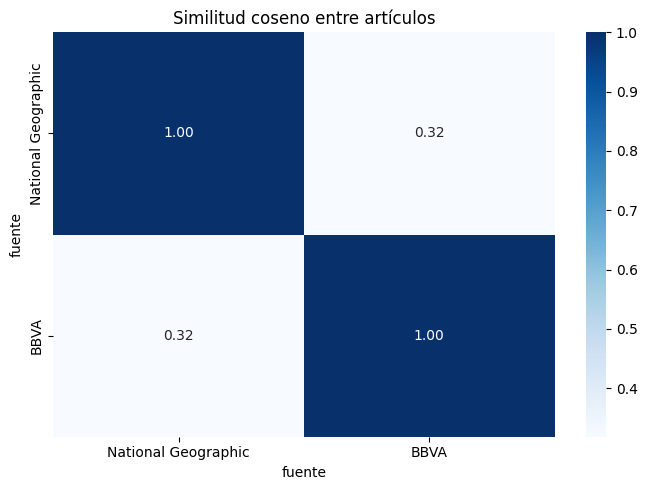

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.heatmap(df_similitud, annot=True, fmt=".2f", cmap="Blues")
plt.title("Similitud coseno entre artículos")
plt.tight_layout()
plt.show()

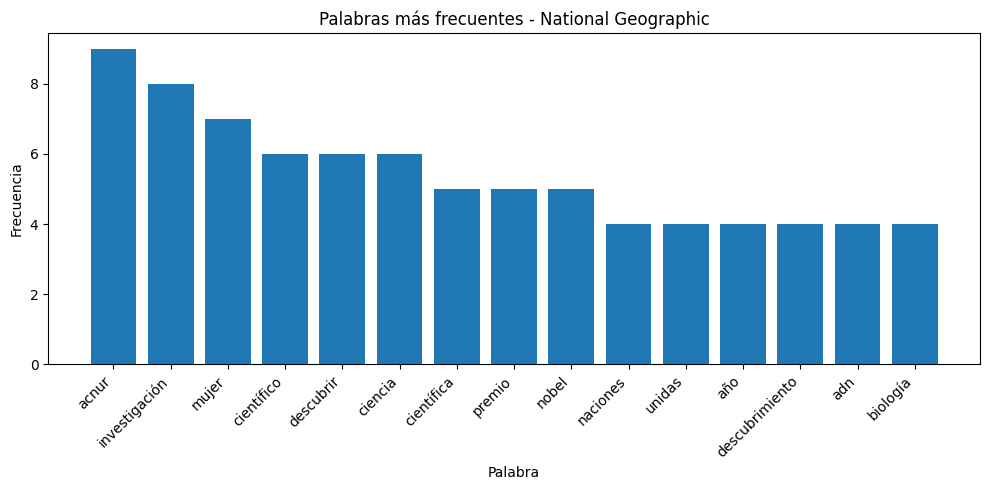

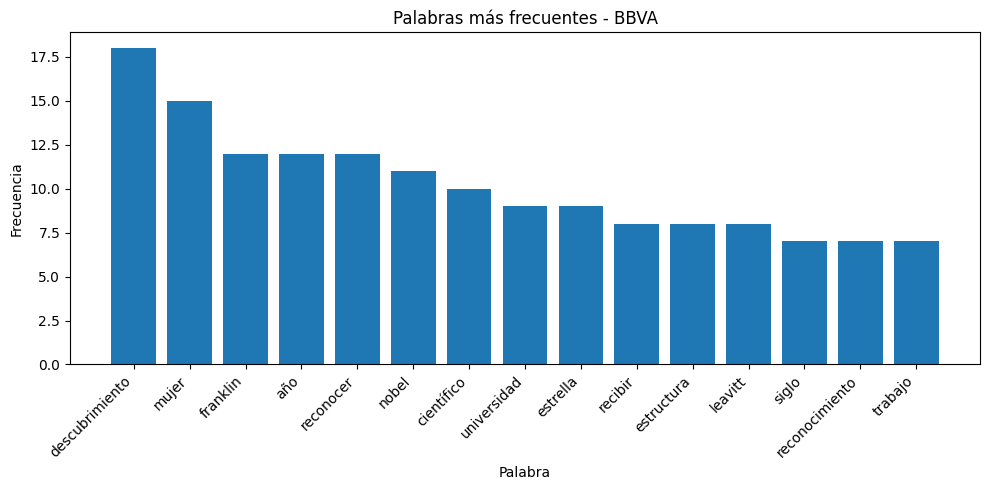

In [24]:
import matplotlib.pyplot as plt

for i, fila in df.iterrows():
    freq = palabras_frecuentes(fila["tokens"], top=15)

    plt.figure(figsize=(10, 5))
    plt.bar(freq["palabra"], freq["frecuencia"])
    plt.title(f"Palabras más frecuentes - {fila['fuente']}")
    plt.xlabel("Palabra")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [25]:
categorias = {
    "ciencia_investigacion": {
        "ciencia", "científica", "científico", "investigación", "investigador",
        "descubrimiento", "laboratorio", "teoría", "estudio", "universidad"
    },
    "reconocimiento_desigualdad": {
        "mujer", "mujeres", "reconocimiento", "discriminación", "género",
        "barrera", "exclusión", "mérito", "olvidada", "igualdad"
    },
    "premios_logros": {
        "nobel", "premio", "galardón", "aportación", "contribución",
        "descubrir", "descubrimiento", "lograr"
    }
}

def contar_categorias(tokens):
    total = len(tokens)
    resultados = {}

    for categoria, palabras in categorias.items():
        conteo = sum(1 for t in tokens if t in palabras)
        resultados[f"conteo_{categoria}"] = conteo
        resultados[f"pct_{categoria}"] = conteo / total if total > 0 else 0

    return pd.Series(resultados)

df_categorias = df["tokens"].apply(contar_categorias)

df_resultado = pd.concat([df, df_categorias], axis=1)

df_resultado[[
    "fuente",
    "num_palabras",
    "palabras_unicas",
    "diversidad_lexica",
    "conteo_ciencia_investigacion",
    "conteo_reconocimiento_desigualdad",
    "conteo_premios_logros",
    "pct_ciencia_investigacion",
    "pct_reconocimiento_desigualdad",
    "pct_premios_logros"
]]

,fuente,num_palabras,palabras_unicas,diversidad_lexica,conteo_ciencia_investigacion,conteo_reconocimiento_desigualdad,conteo_premios_logros,pct_ciencia_investigacion,pct_reconocimiento_desigualdad,pct_premios_logros
0,National Geographic,411,264,0.642336,37.0,10.0,25.0,0.090024,0.024331,0.060827
1,BBVA,1027,572,0.556962,52.0,41.0,47.0,0.050633,0.039922,0.045764


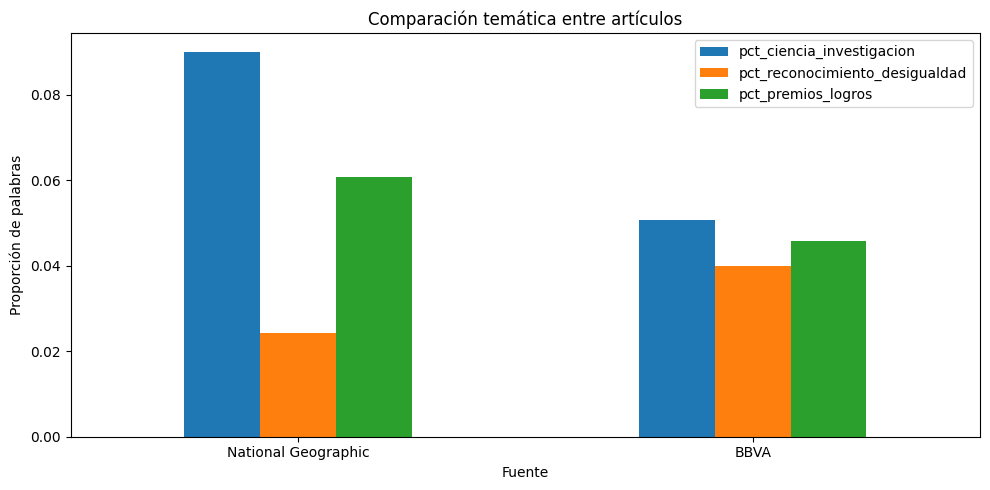

In [26]:
df_plot = df_resultado.set_index("fuente")[
    [
        "pct_ciencia_investigacion",
        "pct_reconocimiento_desigualdad",
        "pct_premios_logros"
    ]
]

df_plot.plot(kind="bar", figsize=(10, 5))

plt.title("Comparación temática entre artículos")
plt.xlabel("Fuente")
plt.ylabel("Proporción de palabras")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()